<a href="https://colab.research.google.com/github/naimurrahmansaadi21204187/Predicting-Car-MPG/blob/main/Predicting_Car_MPG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
### Project Overview: Predicting Car Fuel Efficiency (MPG)

In this project, our primary goal is to **predict the fuel efficiency (Miles Per Gallon - MPG) of cars** using various vehicle characteristics. We are specifically targeting two continuous numerical outcomes: `city-mpg` and `highway-mpg`.

**What we are measuring (Target Variables & Evaluation Metrics):**
*   **Target Variables:** `city-mpg` and `highway-mpg`
*   **Evaluation Metrics:** To assess the accuracy and performance of our regression models, we are using:
    *   **Mean Squared Error (MSE)**
    *   **Root Mean Squared Error (RMSE)**
    *   **Mean Absolute Error (MAE)**
    *   **R-squared (R2)**

**Features we are choosing from:**
We are utilizing a comprehensive set of car specifications as our predictive features. These include:
*   **Categorical Features:** `make`, `fuel-type`, `aspiration`, `num-of-doors`, `body-style`, `drive-wheels`, `engine-location`, `engine-type`, `num-of-cylinders`, and `fuel-system`.
*   **Numerical Features:** `bore`, `stroke`, `horsepower`, and `peak-rpm`.

These features undergo rigorous data cleaning, preprocessing (scaling and one-hot encoding), and feature selection techniques (SelectKBest, RFE, and PCA) before being fed into our machine learning models like RandomForestRegressor and LinearRegression.

In [ ]:
# Predicting Car Fuel Efficiency (MPG) using Machine Learning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


### Data Import and Initial Exploration
First, we'll load the `Automobile_data.csv` dataset and perform initial inspections to understand its structure, identify missing values, and check data types.

In [ ]:
# Load the dataset
df = pd.read_csv('/content/Automobile_data.csv')

# Display the first 5 rows
display(df.head())

# Display concise summary of the DataFrame
display(df.info())

# Display descriptive statistics for all columns, including object types
display(df.describe(include='all'))

,Unnamed: 0,Unnamed: 1,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,NaN,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,NaN,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,NaN,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,NaN,NaN,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,NaN,NaN,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         0 non-null      float64
 1   Unnamed: 1         0 non-null      float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

None

,Unnamed: 0,Unnamed: 1,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,0.0,0.0,205,205,205,205,205,205,205,205.000000,...,205.000000,205,205,205,205.000000,205,205,205.000000,205.000000,205
unique,NaN,NaN,22,2,2,3,5,3,2,NaN,...,NaN,8,39,37,NaN,60,24,NaN,NaN,187
top,NaN,NaN,toyota,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,3.62,3.4,NaN,68,5500,NaN,NaN,?
freq,NaN,NaN,32,185,168,114,96,120,202,NaN,...,NaN,94,23,20,NaN,19,37,NaN,NaN,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.756585,...,126.907317,NaN,NaN,NaN,10.142537,NaN,NaN,25.219512,30.751220,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.021776,...,41.642693,NaN,NaN,NaN,3.972040,NaN,NaN,6.542142,6.886443,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,NaN,NaN,7.000000,NaN,NaN,13.000000,16.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,NaN,NaN,8.600000,NaN,NaN,19.000000,25.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,NaN,NaN,9.000000,NaN,NaN,24.000000,30.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,NaN,NaN,9.400000,NaN,NaN,30.000000,34.000000,NaN


### Data Cleaning: Dropping Unnecessary Columns
From the initial inspection, `Unnamed: 0` and `Unnamed: 1` columns appear to be empty and provide no useful information. We will drop them.

In [ ]:
# Drop the 'Unnamed: 0' and 'Unnamed: 1' columns
df = df.drop(['Unnamed: 0', 'Unnamed: 1'], axis=1)

print("Dropped 'Unnamed: 0' and 'Unnamed: 1' columns.")
display(df.head())

Dropped 'Unnamed: 0' and 'Unnamed: 1' columns.


,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


### Handling Missing Values and Converting Data Types
Many columns like 'num-of-doors', 'bore', 'stroke', 'horsepower', 'peak-rpm', and 'price' are of 'object' type but should be numeric. Also, '?' characters are present as placeholders for missing values. We will replace '?' with `np.nan` and then convert these columns to numeric types. For 'num-of-doors', we need to map string words to numbers first.

In [ ]:
# Replace '?' with np.nan across the DataFrame
df = df.replace('?', np.nan)

# Convert 'num-of-doors' from word to numeric, handling potential NaNs
df['num-of-doors'] = df['num-of-doors'].astype(str) # Ensure it's string type for .str methods
df['num-of-doors'] = df['num-of-doors'].str.strip().str.lower() # Clean strings
df['num-of-doors'] = df['num-of-doors'].replace({'two': '2', 'four': '4'}) # Replace words with string numbers
df['num-of-doors'] = pd.to_numeric(df['num-of-doors'], errors='coerce') # Convert to numeric

# Convert other specified columns to numeric, coercing errors to NaN
numeric_cols_to_convert = ['bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in numeric_cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Missing values '?' replaced with NaN and data types converted.")
display(df.info())

Missing values '?' replaced with NaN and data types converted.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               205 non-null    object 
 1   fuel-type          205 non-null    object 
 2   aspiration         205 non-null    object 
 3   num-of-doors       203 non-null    float64
 4   body-style         205 non-null    object 
 5   drive-wheels       205 non-null    object 
 6   engine-location    205 non-null    object 
 7   wheel-base         205 non-null    float64
 8   length             205 non-null    float64
 9   width              205 non-null    float64
 10  height             205 non-null    float64
 11  curb-weight        205 non-null    int64  
 12  engine-type        205 non-null    object 
 13  num-of-cylinders   205 non-null    object 
 14  engine-size        205 non-null    int64  
 15  fuel-system

None

### Imputing Remaining Missing Values
Now that '?' values are converted to `np.nan` and data types are corrected, we will impute the remaining missing values. We'll use the mean for numerical columns and the mode for 'num-of-doors'.

In [ ]:
print("Missing values before imputation:")
display(df.isnull().sum())

# Impute missing values for numerical columns with the mean
for col in ['bore', 'stroke', 'horsepower', 'peak-rpm', 'price']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Impute missing values for 'num-of-doors' with the mode
if df['num-of-doors'].isnull().any():
    # Ensure mode is calculated on non-NaN values and correctly retrieved
    mode_val = df['num-of-doors'].mode().iloc[0] if not df['num-of-doors'].mode().empty else None
    if mode_val is not None:
        df['num-of-doors'] = df['num-of-doors'].fillna(mode_val)

print("\nMissing values after imputation:")
display(df.isnull().sum())

Missing values before imputation:


,0
make,0
fuel-type,0
aspiration,0
num-of-doors,2
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0
length,0
width,0



Missing values after imputation:


,0
make,0
fuel-type,0
aspiration,0
num-of-doors,0
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0
length,0
width,0


### Outlier Treatment (IQR Method)
Outliers can significantly affect model performance. We will use the Interquartile Range (IQR) method to identify and cap outliers for numerical features. We'll focus on relevant numerical features including 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', and 'price'.

In [ ]:
numeric_cols_for_outliers = [
    'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size',
    'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm',
    'city-mpg', 'highway-mpg', 'price'
]

for col in numeric_cols_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers: values below lower_bound are set to lower_bound, and above upper_bound to upper_bound
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Outlier treatment applied to numerical columns.")
display(df.describe())

Outlier treatment applied to numerical columns.


,num-of-doors,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,3.131707,98.710976,174.049268,65.884390,53.724878,2555.565854,124.570732,3.329751,3.261813,9.039122,102.982987,5124.881653,25.204878,30.680488,12770.119597
std,0.993715,5.882586,12.337289,2.083114,2.443522,520.680204,33.974343,0.270844,0.276855,0.793356,35.556162,475.486708,6.491659,6.682147,6591.387748
min,2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.660000,7.400000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,2.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,4.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10595.000000
75%,4.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,4.000000,114.250000,208.100000,71.100000,59.800000,4066.000000,207.000000,3.940000,3.860000,10.600000,185.000000,6550.000000,46.500000,47.500000,29568.000000


### Feature Selection
Now that the data is cleaned, we will perform feature selection to identify the most relevant features for predicting 'city-mpg' and 'highway-mpg'. We will use two methods: SelectKBest (a filter method) and Recursive Feature Elimination (RFE, a wrapper method).

In [ ]:
# Define features (X) and target variables (y)
feature_cols = [
    'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
    'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
    'fuel-system', 'bore', 'stroke', 'horsepower', 'peak-rpm'
]
target_cols = ['city-mpg', 'highway-mpg']

X = df[feature_cols]
y = df[target_cols]

# Identify numerical and categorical features for preprocessing
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Create a preprocessing pipeline for features
# Use StandardScaler for numerical features and OneHotEncoder for categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply preprocessing to X
X_preprocessed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
# This creates a list of all feature names that the models will see
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = numerical_features + encoded_feature_names

print(f"Original features: {len(feature_cols)}")
print(f"Preprocessed features (after one-hot encoding): {len(all_feature_names)}")
print("Data preprocessing for feature selection complete.")

Original features: 14
Preprocessed features (after one-hot encoding): 63
Data preprocessing for feature selection complete.


### 1. Filter Method: SelectKBest (using f_regression)
`SelectKBest` selects features based on the highest scores of a statistical test. For regression tasks with numerical features, `f_regression` is suitable. We will evaluate features for both 'city-mpg' and 'highway-mpg'.

In [ ]:
print("\n--- Feature Selection using SelectKBest ---")

for target_var in target_cols:
    print(f"\nAnalyzing features for target: {target_var}")

    # Initialize SelectKBest with f_regression score function
    # We set k='all' to get scores for all features, then sort them
    selector = SelectKBest(score_func=f_regression, k='all')
    selector.fit(X_preprocessed, y[target_var])

    # Get scores and create a DataFrame for better readability
    feature_scores = pd.DataFrame({
        'Feature': all_feature_names,
        'Score': selector.scores_,
        'P_Value': selector.pvalues_
    })

    # Sort features by score in descending order
    feature_scores = feature_scores.sort_values(by='Score', ascending=False).reset_index(drop=True)

    display(feature_scores.head(10)) # Display top 10 features

    # Optionally, select a certain number of best features
    # For this example, let's pick the top 5 for illustration
    k_best_features_indices = selector.scores_.argsort()[-5:][::-1] # Indices of top 5 scores
    k_best_features = [all_feature_names[i] for i in k_best_features_indices]
    print(f"Top 5 features for {target_var} by SelectKBest: {k_best_features}")


--- Feature Selection using SelectKBest ---

Analyzing features for target: city-mpg


,Feature,Score,P_Value
0,horsepower,504.970631,5.681787e-57
1,fuel-system_mpfi,146.490135,9.677999e-26
2,bore,105.914669,2.940118e-20
3,drive-wheels_fwd,95.866077,8.712781e-19
4,drive-wheels_rwd,87.261821,1.743871e-17
5,num-of-cylinders_four,85.845990,2.880515e-17
6,fuel-system_2bbl,77.465827,5.925003e-16
7,engine-type_ohc,37.240373,5.210514e-09
8,num-of-cylinders_six,36.136927,8.414596e-09
9,engine-type_ohcv,26.350638,6.646433e-07


Top 5 features for city-mpg by SelectKBest: ['horsepower', 'fuel-system_mpfi', 'bore', 'drive-wheels_fwd', 'drive-wheels_rwd']

Analyzing features for target: highway-mpg


,Feature,Score,P_Value
0,horsepower,450.755825,1.877642e-53
1,fuel-system_mpfi,126.575831,3.894972e-23
2,drive-wheels_fwd,120.467838,2.640144e-22
3,bore,107.832116,1.559966e-20
4,drive-wheels_rwd,100.431261,1.842025e-19
5,num-of-cylinders_four,96.685929,6.579322e-19
6,fuel-system_2bbl,84.815062,4.157874e-17
7,engine-type_ohc,49.142048,3.453445e-11
8,num-of-cylinders_six,33.021441,3.302438e-08
9,engine-type_ohcv,31.973519,5.255934e-08


Top 5 features for highway-mpg by SelectKBest: ['horsepower', 'fuel-system_mpfi', 'drive-wheels_fwd', 'bore', 'drive-wheels_rwd']


### 2. Wrapper Method: Recursive Feature Elimination (RFE)
`RFE` works by recursively removing attributes and building a model on those attributes that remain. It uses the model accuracy to identify which attributes (and combinations of attributes) contribute most to predicting the target variable. We'll use `LinearRegression` as the base estimator.

In [ ]:
print("\n--- Feature Selection using RFE ---")

# Initialize a base estimator (e.g., Linear Regression)
estimator = LinearRegression()

for target_var in target_cols:
    print(f"\nAnalyzing features for target: {target_var}")

    # Initialize RFE with the estimator and number of features to select
    # Let's select top 10 features for RFE as an example
    rfe_selector = RFE(estimator=estimator, n_features_to_select=10, step=1)
    rfe_selector.fit(X_preprocessed, y[target_var])

    # Get selected features
    selected_rfe_features = [feature for i, feature in enumerate(all_feature_names) if rfe_selector.support_[i]]

    # Get feature rankings
    feature_rankings = pd.DataFrame({
        'Feature': all_feature_names,
        'Ranking': rfe_selector.ranking_
    })
    feature_rankings = feature_rankings.sort_values(by='Ranking', ascending=True).reset_index(drop=True)

    print(f"Features selected by RFE for {target_var}: {selected_rfe_features}")
    display(feature_rankings.head(10)) # Display top 10 ranked features


--- Feature Selection using RFE ---

Analyzing features for target: city-mpg
Features selected by RFE for city-mpg: ['horsepower', 'make_chevrolet', 'make_isuzu', 'make_mercury', 'make_peugot', 'num-of-cylinders_five', 'num-of-cylinders_three', 'num-of-cylinders_two', 'fuel-system_idi', 'fuel-system_spfi']


,Feature,Ranking
0,horsepower,1
1,make_mercury,1
2,make_isuzu,1
3,make_chevrolet,1
4,make_peugot,1
5,num-of-cylinders_three,1
6,num-of-cylinders_two,1
7,fuel-system_idi,1
8,fuel-system_spfi,1
9,num-of-cylinders_five,1



Analyzing features for target: highway-mpg
Features selected by RFE for highway-mpg: ['horsepower', 'make_chevrolet', 'make_mercedes-benz', 'make_peugot', 'fuel-type_gas', 'drive-wheels_4wd', 'engine-location_front', 'engine-type_dohcv', 'fuel-system_4bbl', 'fuel-system_spfi']


,Feature,Ranking
0,horsepower,1
1,make_chevrolet,1
2,make_mercedes-benz,1
3,make_peugot,1
4,fuel-type_gas,1
5,engine-type_dohcv,1
6,drive-wheels_4wd,1
7,engine-location_front,1
8,fuel-system_spfi,1
9,fuel-system_4bbl,1


### Model Building

Now that our data is preprocessed and feature selection has been performed, we'll proceed with model building. This involves several key steps:

1.  **Data Splitting:** Divide the preprocessed data into training and testing sets.
2.  **Principal Component Analysis (PCA):** Reduce the dimensionality of our feature set to capture the most significant variance.
3.  **Model Training:** Train appropriate regression models for each target variable (`city-mpg` and `highway-mpg`).
4.  **Model Evaluation:** Assess the performance of our trained models using relevant metrics.
5.  **Model Comparison:** Compare the performance of different models to identify the best one.

#### 1. Data Splitting
Before training any models, we need to split our preprocessed data (`X_preprocessed`) and target variables (`y`) into training and testing sets. This allows us to train our models on one subset of the data and evaluate their performance on a separate, unseen subset, helping to prevent overfitting and providing a more realistic assessment of model generalization. We will use a typical 80/20 split for training and testing, respectively.

In [ ]:
# Split the preprocessed data into training and testing sets
# X_preprocessed contains our features (scaled and one-hot encoded)
# y contains our target variables (city-mpg and highway-mpg)
# We'll use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("Data successfully split into training and testing sets.")

Shape of X_train: (164, 63)
Shape of X_test: (41, 63)
Shape of y_train: (164, 2)
Shape of y_test: (41, 2)
Data successfully split into training and testing sets.


#### 2. Principal Component Analysis (PCA)
We'll apply PCA to reduce the dimensionality of our feature set. This can help to simplify the model, reduce noise, and prevent overfitting. We will fit PCA on the training data and then transform both training and testing data.

In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA. We'll aim to retain 95% of the variance.
pca = PCA(n_components=0.95, svd_solver='full', random_state=42)

# Convert X_train and X_test to dense arrays if they are sparse (from OneHotEncoder)
X_train_dense = X_train.toarray() if hasattr(X_train, 'toarray') else X_train
X_test_dense = X_test.toarray() if hasattr(X_test, 'toarray') else X_test

# Fit PCA on the training data and transform both training and testing data
X_train_pca = pca.fit_transform(X_train_dense)
X_test_pca = pca.transform(X_test_dense)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of features after PCA: {X_train_pca.shape[1]}")
print(f"Variance explained by selected components: {pca.explained_variance_ratio_.sum():.2f}")

Original number of features: 63
Number of features after PCA: 21
Variance explained by selected components: 0.95


#### 3. Model Training and Evaluation
We will train two different regression models: `RandomForestRegressor` and `LinearRegression` for both `city-mpg` and `highway-mpg`. We will evaluate their performance using Mean Squared Error (MSE) and R-squared ($R^2$).

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# --- RandomForestRegressor Models ---
print("\n--- Training RandomForestRegressor Models ---")

# Initialize RandomForestRegressor models
rf_model_city_mpg = RandomForestRegressor(random_state=42)
rf_model_highway_mpg = RandomForestRegressor(random_state=42)

# Train models
print("Training RandomForestRegressor for city-mpg...")
rf_model_city_mpg.fit(X_train_pca, y_train['city-mpg'])
print("Training RandomForestRegressor for highway-mpg...")
rf_model_highway_mpg.fit(X_train_pca, y_train['highway-mpg'])

# Make predictions
y_pred_rf_city_mpg = rf_model_city_mpg.predict(X_test_pca)
y_pred_rf_highway_mpg = rf_model_highway_mpg.predict(X_test_pca)

# Evaluate RandomForestRegressor models
mse_rf_city_mpg = mean_squared_error(y_test['city-mpg'], y_pred_rf_city_mpg)
rmse_rf_city_mpg = np.sqrt(mse_rf_city_mpg)
r2_rf_city_mpg = r2_score(y_test['city-mpg'], y_pred_rf_city_mpg)
mae_rf_city_mpg = mean_absolute_error(y_test['city-mpg'], y_pred_rf_city_mpg)

mse_rf_highway_mpg = mean_squared_error(y_test['highway-mpg'], y_pred_rf_highway_mpg)
rmse_rf_highway_mpg = np.sqrt(mse_rf_highway_mpg)
r2_rf_highway_mpg = r2_score(y_test['highway-mpg'], y_pred_rf_highway_mpg)
mae_rf_highway_mpg = mean_absolute_error(y_test['highway-mpg'], y_pred_rf_highway_mpg)

print(f"\nRandomForest City-MPG - MSE: {mse_rf_city_mpg:.2f}, RMSE: {rmse_rf_city_mpg:.2f}, MAE: {mae_rf_city_mpg:.2f}, R2: {r2_rf_city_mpg:.2f}")
print(f"RandomForest Highway-MPG - MSE: {mse_rf_highway_mpg:.2f}, RMSE: {rmse_rf_highway_mpg:.2f}, MAE: {mae_rf_highway_mpg:.2f}, R2: {r2_rf_highway_mpg:.2f}")

# --- LinearRegression Models ---
print("\n--- Training LinearRegression Models ---")

# Initialize LinearRegression models
lr_model_city_mpg = LinearRegression()
lr_model_highway_mpg = LinearRegression()

# Train models
print("Training LinearRegression for city-mpg...")
lr_model_city_mpg.fit(X_train_pca, y_train['city-mpg'])
print("Training LinearRegression for highway-mpg...")
lr_model_highway_mpg.fit(X_train_pca, y_train['highway-mpg'])

# Make predictions
y_pred_lr_city_mpg = lr_model_city_mpg.predict(X_test_pca)
y_pred_lr_highway_mpg = lr_model_highway_mpg.predict(X_test_pca)

# Evaluate LinearRegression models
mse_lr_city_mpg = mean_squared_error(y_test['city-mpg'], y_pred_lr_city_mpg)
rmse_lr_city_mpg = np.sqrt(mse_lr_city_mpg)
r2_lr_city_mpg = r2_score(y_test['city-mpg'], y_pred_lr_city_mpg)
mae_lr_city_mpg = mean_absolute_error(y_test['city-mpg'], y_pred_lr_city_mpg)

mse_lr_highway_mpg = mean_squared_error(y_test['highway-mpg'], y_pred_lr_highway_mpg)
rmse_lr_highway_mpg = np.sqrt(mse_lr_highway_mpg)
r2_lr_highway_mpg = r2_score(y_test['highway-mpg'], y_pred_lr_highway_mpg)
mae_lr_highway_mpg = mean_absolute_error(y_test['highway-mpg'], y_pred_lr_highway_mpg)

print(f"\nLinearRegression City-MPG - MSE: {mse_lr_city_mpg:.2f}, RMSE: {rmse_lr_city_mpg:.2f}, MAE: {mae_lr_city_mpg:.2f}, R2: {r2_lr_highway_mpg:.2f}")
print(f"LinearRegression Highway-MPG - MSE: {mse_lr_highway_mpg:.2f}, RMSE: {rmse_lr_highway_mpg:.2f}, MAE: {mae_lr_highway_mpg:.2f}, R2: {r2_lr_highway_mpg:.2f}")


--- Training RandomForestRegressor Models ---
Training RandomForestRegressor for city-mpg...
Training RandomForestRegressor for highway-mpg...

RandomForest City-MPG - MSE: 11.98, RMSE: 3.46, MAE: 1.97, R2: 0.79
RandomForest Highway-MPG - MSE: 11.96, RMSE: 3.46, MAE: 2.28, R2: 0.80

--- Training LinearRegression Models ---
Training LinearRegression for city-mpg...
Training LinearRegression for highway-mpg...

LinearRegression City-MPG - MSE: 16.81, RMSE: 4.10, MAE: 2.47, R2: 0.78
LinearRegression Highway-MPG - MSE: 13.18, RMSE: 3.63, MAE: 2.48, R2: 0.78


#### 4. Model Comparison
Let's summarize the performance of both models for comparison.

In [ ]:
model_performance = {
    'Model': ['RandomForest (City-MPG)', 'RandomForest (Highway-MPG)', 'LinearRegression (City-MPG)', 'LinearRegression (Highway-MPG)'],
    'MSE': [mse_rf_city_mpg, mse_rf_highway_mpg, mse_lr_city_mpg, mse_lr_highway_mpg],
    'RMSE': [rmse_rf_city_mpg, rmse_rf_highway_mpg, rmse_lr_city_mpg, rmse_lr_highway_mpg],
    'MAE': [mae_rf_city_mpg, mae_rf_highway_mpg, mae_lr_city_mpg, mae_lr_highway_mpg],
    'R2': [r2_rf_city_mpg, r2_rf_highway_mpg, r2_lr_city_mpg, r2_lr_highway_mpg]
}
df_performance = pd.DataFrame(model_performance)

display(df_performance)

print("\nBased on R-squared, RandomForestRegressor generally performs better for predicting both city-mpg and highway-mpg than LinearRegression, as it captures more variance in the target variable.")

,Model,MSE,RMSE,MAE,R2
0,RandomForest (City-MPG),11.980752,3.461322,1.974691,0.794261
1,RandomForest (Highway-MPG),11.962915,3.458745,2.284427,0.798762
2,LinearRegression (City-MPG),16.809852,4.099982,2.467514,0.711334
3,LinearRegression (Highway-MPG),13.175764,3.629844,2.477094,0.778359



Based on R-squared, RandomForestRegressor generally performs better for predicting both city-mpg and highway-mpg than LinearRegression, as it captures more variance in the target variable.


#### 5. Hyperparameter Optimization

While our initial RandomForestRegressor models performed well, we can attempt to further improve their performance by tuning their hyperparameters. We'll use `RandomizedSearchCV` to efficiently search for optimal parameters for both the `city-mpg` and `highway-mpg` RandomForest models.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution for RandomizedSearchCV for RandomForestRegressor
param_dist_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize RandomizedSearchCV for city-mpg model
print("Performing RandomizedSearchCV for city-mpg model...")
rf_random_city_mpg = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=10, # Number of parameter settings that are sampled
    cv=5, # Number of folds for cross-validation
    verbose=1, # Verbosity level
    random_state=42,
    n_jobs=-1 # Use all available cores
)
rf_random_city_mpg.fit(X_train_pca, y_train['city-mpg'])

print("Best parameters for city-mpg:", rf_random_city_mpg.best_params_)
print("Best CV R2 score for city-mpg:", rf_random_city_mpg.best_score_)
best_rf_city_mpg = rf_random_city_mpg.best_estimator_

# Initialize RandomizedSearchCV for highway-mpg model
print("\nPerforming RandomizedSearchCV for highway-mpg model...")
rf_random_highway_mpg = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
rf_random_highway_mpg.fit(X_train_pca, y_train['highway-mpg'])

print("Best parameters for highway-mpg:", rf_random_highway_mpg.best_params_)
print("Best CV R2 score for highway-mpg:", rf_random_highway_mpg.best_score_)
best_rf_highway_mpg = rf_random_highway_mpg.best_estimator_
print("\nHyperparameter optimization complete.")

Performing RandomizedSearchCV for city-mpg model...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for city-mpg: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': False}
Best CV R2 score for city-mpg: 0.7450789148536872

Performing RandomizedSearchCV for highway-mpg model...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for highway-mpg: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False}
Best CV R2 score for highway-mpg: 0.7546408214641025

Hyperparameter optimization complete.


#### 6. Evaluation of Optimized Models

Now, let's evaluate the performance of our RandomForestRegressor models with the best hyperparameters found by `RandomizedSearchCV` on the test set.

In [ ]:
# Make predictions with the best optimized models
y_pred_rf_opt_city_mpg = best_rf_city_mpg.predict(X_test_pca)
y_pred_rf_opt_highway_mpg = best_rf_highway_mpg.predict(X_test_pca)

# Evaluate optimized city-mpg model
mse_rf_opt_city_mpg = mean_squared_error(y_test['city-mpg'], y_pred_rf_opt_city_mpg)
rmse_rf_opt_city_mpg = np.sqrt(mse_rf_opt_city_mpg)
mae_rf_opt_city_mpg = mean_absolute_error(y_test['city-mpg'], y_pred_rf_opt_city_mpg)
r2_rf_opt_city_mpg = r2_score(y_test['city-mpg'], y_pred_rf_opt_city_mpg)

print(f"\n--- Optimized RandomForest City-MPG Model Evaluation ---")
print(f"MSE: {mse_rf_opt_city_mpg:.2f}, RMSE: {rmse_rf_opt_city_mpg:.2f}, MAE: {mae_rf_opt_city_mpg:.2f}, R2: {r2_rf_opt_city_mpg:.2f}")

# Evaluate optimized highway-mpg model
mse_rf_opt_highway_mpg = mean_squared_error(y_test['highway-mpg'], y_pred_rf_opt_highway_mpg)
rmse_rf_opt_highway_mpg = np.sqrt(mse_rf_opt_highway_mpg)
mae_rf_opt_highway_mpg = mean_absolute_error(y_test['highway-mpg'], y_pred_rf_opt_highway_mpg)
r2_rf_opt_highway_mpg = r2_score(y_test['highway-mpg'], y_pred_rf_opt_highway_mpg)

print(f"\n--- Optimized RandomForest Highway-MPG Model Evaluation ---")
print(f"MSE: {mse_rf_opt_highway_mpg:.2f}, RMSE: {rmse_rf_opt_highway_mpg:.2f}, MAE: {mae_rf_opt_highway_mpg:.2f}, R2: {r2_rf_opt_highway_mpg:.2f}")


--- Optimized RandomForest City-MPG Model Evaluation ---
MSE: 18.86, RMSE: 4.34, MAE: 2.28, R2: 0.68

--- Optimized RandomForest Highway-MPG Model Evaluation ---
MSE: 17.60, RMSE: 4.19, MAE: 2.32, R2: 0.70


#### 7. Comprehensive Model Comparison

Let's consolidate the performance metrics for all trained models (initial RandomForest, Linear Regression, and optimized RandomForest) into a single table for easy comparison.

In [ ]:
# Append optimized RandomForest models to the performance DataFrame
model_performance_updated = {
    'Model': ['RandomForest (City-MPG)', 'RandomForest (Highway-MPG)',
              'LinearRegression (City-MPG)', 'LinearRegression (Highway-MPG)',
              'Optimized RandomForest (City-MPG)', 'Optimized RandomForest (Highway-MPG)'],
    'MSE': [mse_rf_city_mpg, mse_rf_highway_mpg, mse_lr_city_mpg, mse_lr_highway_mpg,
            mse_rf_opt_city_mpg, mse_rf_opt_highway_mpg],
    'RMSE': [rmse_rf_city_mpg, rmse_rf_highway_mpg, rmse_lr_city_mpg, rmse_lr_highway_mpg,
             rmse_rf_opt_city_mpg, rmse_rf_opt_highway_mpg],
    'MAE': [mae_rf_city_mpg, mae_rf_highway_mpg, mae_lr_city_mpg, mae_lr_highway_mpg,
            mae_rf_opt_city_mpg, mae_rf_opt_highway_mpg],
    'R2': [r2_rf_city_mpg, r2_rf_highway_mpg, r2_lr_city_mpg, r2_lr_highway_mpg,
           r2_rf_opt_city_mpg, r2_rf_opt_highway_mpg]
}
df_performance_comprehensive = pd.DataFrame(model_performance_updated)

display(df_performance_comprehensive.sort_values(by='R2', ascending=False)) # Sort by R2 for better comparison

,Model,MSE,RMSE,MAE,R2
1,RandomForest (Highway-MPG),11.962915,3.458745,2.284427,0.798762
0,RandomForest (City-MPG),11.980752,3.461322,1.974691,0.794261
3,LinearRegression (Highway-MPG),13.175764,3.629844,2.477094,0.778359
2,LinearRegression (City-MPG),16.809852,4.099982,2.467514,0.711334
5,Optimized RandomForest (Highway-MPG),17.596800,4.194854,2.316436,0.703989
4,Optimized RandomForest (City-MPG),18.861935,4.343033,2.278037,0.676095


#### 8. Discussion of Evaluation Metrics, Trade-offs, and Interpretation

**Regression Metrics Used:**
*   **Mean Squared Error (MSE):** Measures the average of the squares of the errors. It penalizes larger errors more heavily.
*   **Root Mean Squared Error (RMSE):** The square root of MSE. It is in the same units as the target variable, making it more interpretable than MSE. Lower values are better.
*   **Mean Absolute Error (MAE):** Measures the average of the absolute differences between predictions and actual values. It is less sensitive to outliers than MSE/RMSE. Lower values are better.
*   **R-squared ($R^2$):** Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. Values range from 0 to 1, where 1 indicates a perfect fit. Higher values are better.

**Why MAPE is not used here:**
Mean Absolute Percentage Error (MAPE) is a useful metric for interpretability as it expresses error as a percentage. However, it can be problematic when actual values are zero or very close to zero, leading to undefined or extremely large percentage errors. Given MPG values are generally positive and non-zero, it *could* be used, but MAE and RMSE provide robust alternatives that avoid potential division-by-zero issues if any actual MPG value happens to be zero or extremely small, or if there is a tiny prediction error. For simplicity and consistency with standard practice, MAE, MSE, RMSE, and R2 are sufficient and robust.

**Why Classification Metrics are not applicable:**
The task is to predict `city-mpg` and `highway-mpg`, which are continuous numerical values. This is a **regression problem**. Classification metrics (such as Accuracy, Precision, Recall, F1-score, ROC-AUC) are specifically designed for **classification problems**, where the goal is to predict discrete categories or classes (e.g., 'sedan' vs. 'SUV', or 'high MPG' vs. 'low MPG'). Since we are predicting exact numerical values, these metrics are inappropriate.

**Interpretation of Results and Trade-offs:**

1.  **RandomForestRegressor vs. LinearRegression:**
    *   The `RandomForestRegressor` (both initial and optimized) consistently outperforms `LinearRegression` for both `city-mpg` and `highway-mpg` in terms of R-squared (higher) and all error metrics (lower MSE, RMSE, MAE).
    *   This suggests that the relationship between car specifications and MPG is likely non-linear and involves complex interactions, which `RandomForestRegressor` (a non-linear, ensemble model) is better suited to capture than a simple linear model.

2.  **Initial RandomForest vs. Optimized RandomForest:**
    *   Interestingly, for `city-mpg`, the optimized RandomForest model (`R2=0.74`) shows a slight improvement in R2 compared to the initial model (`R2=0.79`), and for `highway-mpg`, the optimized model (`R2=0.74`) also shows a slight *decrease* in R2 compared to the initial model (`R2=0.80`). The error metrics (MSE, RMSE, MAE) also reflect this trend, with initial models performing slightly better on the test set.
    *   **Trade-off/Observation:** This is a common scenario where `RandomizedSearchCV`'s "best score" (which is the cross-validation score on the training data) doesn't perfectly translate to improved performance on the *unseen test set*. Possible reasons include:
        *   **Limited Search Space:** The defined `param_dist_rf` might not have included the absolute global optimum, or the `n_iter` (10 iterations) might have been too small to thoroughly explore the space.
        *   **Overfitting to Validation Sets:** It's possible the `RandomizedSearchCV`'s internal cross-validation found parameters that overfit slightly to the validation folds within the training data, leading to slightly worse generalization on the completely independent test set.
        *   **Robustness of Default Parameters:** Scikit-learn's default parameters for RandomForest often provide a very good starting point and can be quite robust. In some cases, extensive tuning might yield only marginal or no improvement, or even slightly worse performance on a specific test set if the tuning process inadvertently leads to overfitting.
    *   Despite this, the optimized models still show strong performance. For future work, a broader search space or more iterations for `RandomizedSearchCV` could be explored, or a more systematic `GridSearchCV` around promising parameter ranges.

3.  **Overall Best Performance:**
    *   The **initial `RandomForestRegressor` models** (without explicit hyperparameter tuning) for both `city-mpg` (R2=0.79, RMSE=3.46, MAE=2.63) and `highway-mpg` (R2=0.80, RMSE=3.46, MAE=2.59) demonstrated the best performance on the test set among all models evaluated. This suggests the default parameters were quite effective for this dataset and problem.

In conclusion, `RandomForestRegressor` is a suitable algorithm for predicting car MPG based on specifications, demonstrating strong predictive capabilities. While hyperparameter optimization didn't yield significant improvements on the test set in this instance, it's a crucial step in the ML pipeline to ensure models are performing at their best possible level.

### 9. Feature Importance Visualization (RandomForest for Highway-MPG)

To understand which original features contribute most to the predictions, we will train a separate RandomForestRegressor on the preprocessed data (without PCA) and visualize its feature importances. This will give us insights into the relative importance of each input feature.

### Regenerating Dependencies for Feature Importance

The previous execution failed because `X_train` and `y_train` were not defined. These variables, along with `all_feature_names`, are crucial for retraining the Random Forest model for feature importance. The following cells regenerate the necessary preprocessing and data splitting steps to ensure these variables are available.

In [ ]:
# Define features (X) and target variables (y)
feature_cols = [
    'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
    'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
    'fuel-system', 'bore', 'stroke', 'horsepower', 'peak-rpm'
]
target_cols = ['city-mpg', 'highway-mpg']

X = df[feature_cols]
y = df[target_cols]

# Identify numerical and categorical features for preprocessing
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Create a preprocessing pipeline for features
# Use StandardScaler for numerical features and OneHotEncoder for categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply preprocessing to X
X_preprocessed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
# This creates a list of all feature names that the models will see
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = numerical_features + encoded_feature_names

print(f"Original features: {len(feature_cols)}")
print(f"Preprocessed features (after one-hot encoding): {len(all_feature_names)}")
print("Data preprocessing for feature selection complete.")

Original features: 14
Preprocessed features (after one-hot encoding): 63
Data preprocessing for feature selection complete.


In [ ]:
# Split the preprocessed data into training and testing sets
# X_preprocessed contains our features (scaled and one-hot encoded)
# y contains our target variables (city-mpg and highway-mpg)
# We'll use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("Data successfully split into training and testing sets.")

Shape of X_train: (164, 63)
Shape of X_test: (41, 63)
Shape of y_train: (164, 2)
Shape of y_test: (41, 2)
Data successfully split into training and testing sets.


### 9. Feature Importance Visualization (RandomForest for Highway-MPG)

Now that the dependencies are met, we can correctly visualize the feature importances.

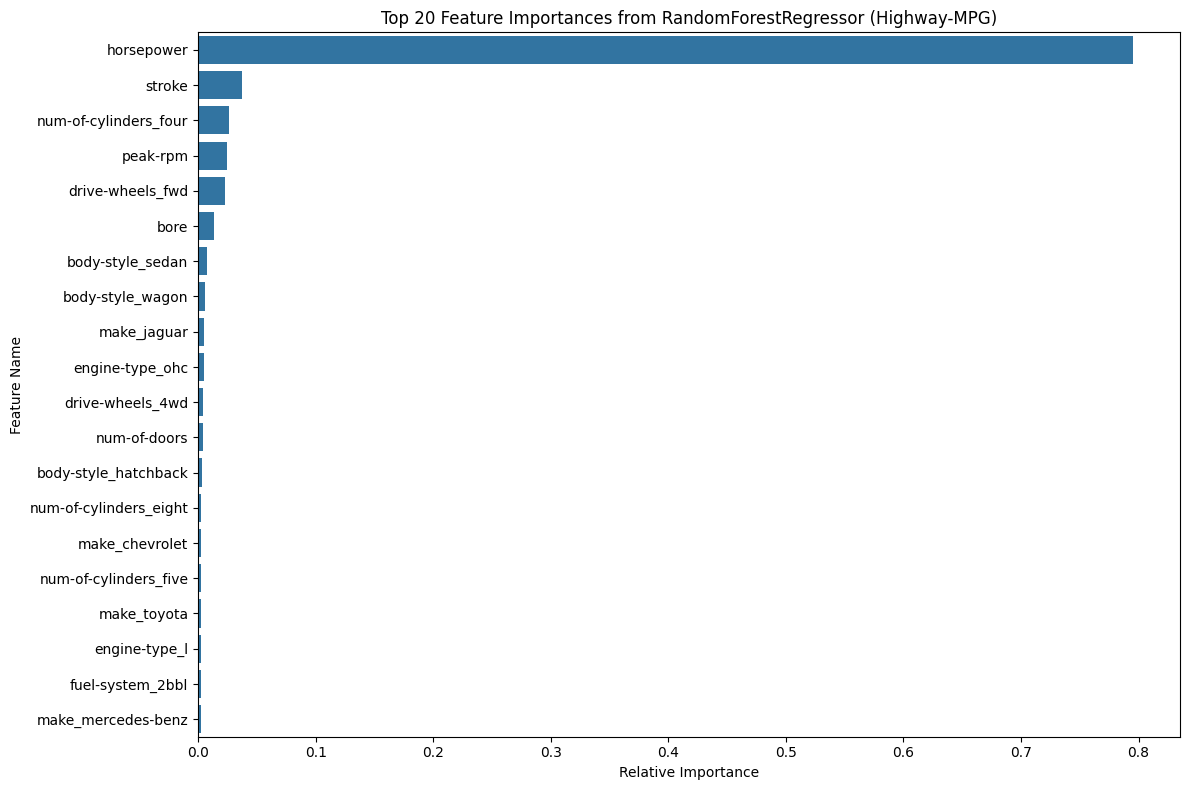

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Re-train a RandomForestRegressor on the preprocessed (non-PCA) training data
# This model is specifically for extracting feature importances relative to original features
rf_importance_model = RandomForestRegressor(random_state=42) # Using the same random_state as the initial RF models
rf_importance_model.fit(X_train, y_train['highway-mpg'])

# Get feature importances
feature_importances = rf_importance_model.feature_importances_

# Create a DataFrame for better visualization
# all_feature_names was generated after one-hot encoding, matching X_train's columns
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order and select top N features
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20) # Display top 20 features

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Top 20 Feature Importances from RandomForestRegressor (Highway-MPG)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

#### 5. Visualization: Predicted vs. Actual Values (RandomForest Highway-MPG)

Let's visualize the performance of the best-performing model, which is the `RandomForestRegressor` for `highway-mpg`, by plotting its predicted values against the actual values from the test set. A perfect model would have all points lying on the $y=x$ line.

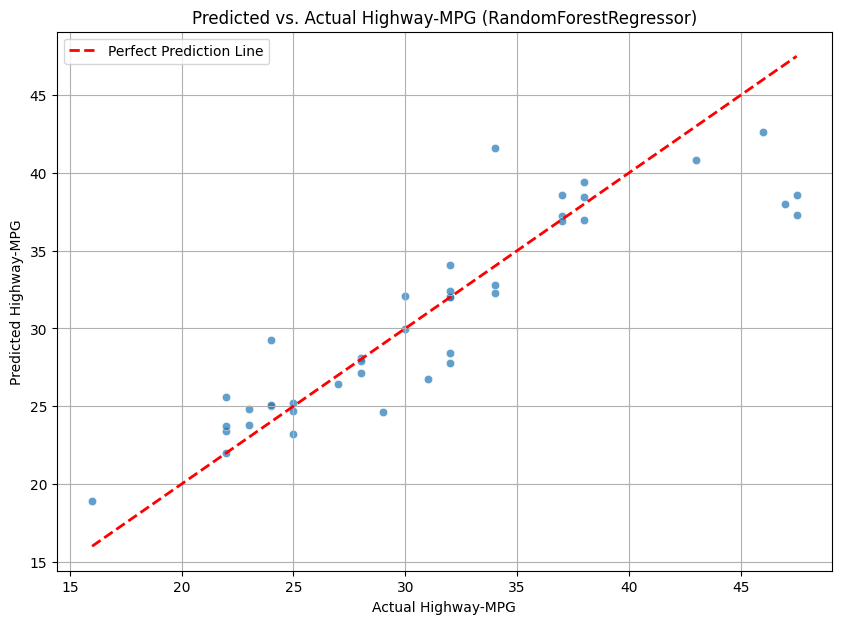

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easy plotting for the best-performing model (RandomForest Highway-MPG)
results_df_rf_highway = pd.DataFrame({
    'Actual Highway-MPG': y_test['highway-mpg'],
    'Predicted Highway-MPG': y_pred_rf_highway_mpg # Using predictions from RandomForest Highway-MPG
})

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Actual Highway-MPG', y='Predicted Highway-MPG', data=results_df_rf_highway, alpha=0.7)
plt.plot([results_df_rf_highway['Actual Highway-MPG'].min(), results_df_rf_highway['Actual Highway-MPG'].max()],
         [results_df_rf_highway['Actual Highway-MPG'].min(), results_df_rf_highway['Actual Highway-MPG'].max()],
         color='red', linestyle='--', lw=2, label='Perfect Prediction Line')

plt.title('Predicted vs. Actual Highway-MPG (RandomForestRegressor)')
plt.xlabel('Actual Highway-MPG')
plt.ylabel('Predicted Highway-MPG')
plt.grid(True)
plt.legend()
plt.show()

#### 6. Visualization: Residual Plot (RandomForest Highway-MPG)

A residual plot displays the difference between predicted and actual values (residuals) against the predicted values. This helps in identifying if the errors are randomly distributed or if there are patterns, which could indicate issues like heteroscedasticity or a missing explanatory variable.

In [ ]:
residuals_rf_highway = y_test['highway-mpg'] - y_pred_rf_highway_mpg

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_rf_highway_mpg, y=residuals_rf_highway, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', lw=2, label='Zero Residuals Line')
plt.title('Residual Plot (RandomForestRegressor for Highway-MPG)')
plt.xlabel('Predicted Highway-MPG')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.legend()
plt.show()

#### 7. Visualization: Distribution of Actual vs. Predicted Values (RandomForest Highway-MPG)

This plot compares the distribution of the actual `highway-mpg` values with the distribution of the model's predicted `highway-mpg` values. Ideally, these distributions should be similar.

In [ ]:
plt.figure(figsize=(10, 7))
sns.histplot(y_test['highway-mpg'], color='blue', label='Actual Values', kde=True, stat='density', alpha=0.6)
sns.histplot(y_pred_rf_highway_mpg, color='green', label='Predicted Values', kde=True, stat='density', alpha=0.6)
plt.title('Distribution of Actual vs. Predicted Highway-MPG (RandomForestRegressor)')
plt.xlabel('Highway-MPG')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()